In [231]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import PowerTransformer


In [232]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [233]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [234]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [235]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [236]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [237]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [238]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [239]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [240]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [241]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [242]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [243]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [244]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [245]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [246]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [247]:
original_X = X.copy()

In [248]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_std = pt.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [249]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.785036,1.828592,-0.293151,0.726273,-0.360668,-0.421860,0.669266,-1.164445,-0.785034,-1.533345,-0.964653,0.750782,0.080033,0.343545
1,-0.746998,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.397233,-0.964653,-1.213660,-1.722060,-1.657833
2,-0.175256,-0.546869,3.411211,-1.376893,-0.360668,-0.421860,0.669266,-1.164445,1.273829,0.830437,1.036642,-0.474112,0.735716,0.318631
3,1.371631,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.727938,-0.964653,-1.992620,-1.291020,-1.835650
4,0.987008,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,1.144253,-0.964653,-1.106304,-0.816679,-1.003396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.007949,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.533345,-0.964653,-0.158214,-0.822461,-0.611074
135,1.111443,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.533345,1.036642,-0.632361,1.008070,0.474941
136,-0.370651,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,0.786825,-0.964653,0.658564,-0.170908,0.133612
137,0.696583,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,1.554125,1.036642,-0.551725,0.574668,0.197985


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

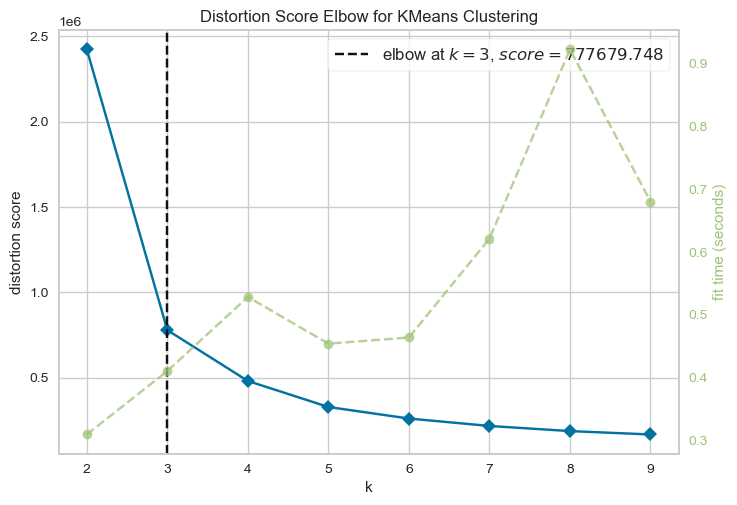

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [250]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [251]:
num_clusters = 3 
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: histgrade_high
Correlation coefficient: 1.0072463768115951


1
Most correlated column: larynx
Correlation coefficient: 1.007246376811598


2
Most correlated column: MTV
Correlation coefficient: 1.0072463768115945




In [252]:
selected_features

['histgrade_high', 'larynx', 'MTV']

In [253]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [254]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)
X_new_std = X_new_std[X_new.columns]

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [255]:
X_new

,histgrade_high,larynx,MTV
0,1,0,7.934
1,0,1,1.656
2,1,0,14.502
3,0,1,2.440
4,0,1,3.668
...,...,...,...
134,1,0,3.650
135,1,0,18.967
136,1,0,6.370
137,1,0,12.443


In [256]:
X_new_std

,histgrade_high,larynx,MTV
0,1,0,0.080033
1,0,1,-1.722060
2,1,0,0.735716
3,0,1,-1.291020
4,0,1,-0.816679
...,...,...,...
134,1,0,-0.822461
135,1,0,1.008070
136,1,0,-0.170908
137,1,0,0.574668


In [257]:
MAASTRO_new

,histgrade_high,larynx,MTV
0,1,0,22.841
1,0,0,5.660
2,0,0,7.791
3,1,1,7.908
4,1,0,15.237
...,...,...,...
94,0,1,6.110
95,0,1,7.182
96,1,0,16.483
97,1,0,9.981


In [258]:
MAASTRO_new_std

,histgrade_high,larynx,MTV
0,1,0,1.188930
1,0,0,-0.307894
2,0,0,0.059450
3,1,1,0.076321
4,1,0,0.786849
...,...,...,...
94,0,1,-0.219083
95,0,1,-0.033134
96,1,0,0.867254
97,1,0,0.336049


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [259]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:58:09,294] A new study created in memory with name: no-name-999ade65-4e7a-4c1d-bf2c-ebc0c0950a9f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.6127450980392157


[I 2024-04-13 23:58:10,920] A new study created in memory with name: no-name-81604f49-9115-45b4-8a21-435b6cdc37ac


Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:10,913] Trial 0 finished with value: 0.6584772664961542 and parameters: {}. Best is trial 0 with value: 0.6584772664961542.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6584772664961542], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 9, 815352), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 10, 912725), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6584772664961542


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22167756398090446
Fold 2 IBS: 0.20671701970871634
Fold 3 IBS: 0.1782941627592951
Fold 4 IBS: 0.17437033623381015
Fold 5 IBS: 0.22531129509758493
[I 2024-04-13 23:58:12,497] Trial 0 finished with value: 0.2012740755560622 and parameters: {}. Best is trial 0 with value: 0.2012740755560622.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2012740755560622], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 11, 119934), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 12, 496924), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2012740755560622


In [260]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [261]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.201


#### Test

In [262]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [263]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.54
IBS score: 0.247


In [264]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [265]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [266]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:58:13,351] A new study created in memory with name: no-name-1bb75db4-0a85-4c3d-9ce3-c2241d5a75bc


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.49567099567099565
Fold 2 C-index: 0.6852678571428571
Fold 3 C-index: 0.5171568627450981
Fold 4 C-index: 0.5611814345991561


[I 2024-04-13 23:58:15,103] A new study created in memory with name: no-name-dee2ad5a-8b69-4070-956f-2f97a52f241c


Fold 5 C-index: 0.6150234741784038
[I 2024-04-13 23:58:15,093] Trial 0 finished with value: 0.5748601248673021 and parameters: {}. Best is trial 0 with value: 0.5748601248673021.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5748601248673021], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 13, 959637), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 15, 93433), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5748601248673021


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652216180973
Fold 2 IBS: 0.2215779153718153
Fold 3 IBS: 0.20453594526928656
Fold 4 IBS: 0.2247380391397073
Fold 5 IBS: 0.21812431260010873
[I 2024-04-13 23:58:16,377] Trial 0 finished with value: 0.21659054690854548 and parameters: {}. Best is trial 0 with value: 0.21659054690854548.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054690854548], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 15, 166753), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 16, 376326), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054690854548


In [267]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [268]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.575
train_ibs:  0.217


#### Test

In [269]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [270]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.551


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [271]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [272]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:58:17,545] A new study created in memory with name: no-name-7023a7ae-039d-4539-a3c1-b4c1b5f556bc


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7848101265822784


[I 2024-04-13 23:58:19,559] A new study created in memory with name: no-name-37fb2d52-98ea-4ff2-b9cf-8bdcd425a1e3


Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:19,525] Trial 0 finished with value: 0.6575844093532971 and parameters: {}. Best is trial 0 with value: 0.6575844093532971.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6575844093532971], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 17, 810005), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 19, 522740), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6575844093532971


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22150448253233906
Fold 2 IBS: 0.20736324385142657
Fold 3 IBS: 0.17866032476641555
Fold 4 IBS: 0.17546625233980637
Fold 5 IBS: 0.22445242788819497
[I 2024-04-13 23:58:21,725] Trial 0 finished with value: 0.2014893462756365 and parameters: {}. Best is trial 0 with value: 0.2014893462756365.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2014893462756365], datetime_start=datetime.datetime(2024, 4, 13, 23, 58, 19, 840430), datetime_complete=datetime.datetime(2024, 4, 13, 23, 58, 21, 708183), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2014893462756365


In [273]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [274]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.201


#### Test

In [275]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [276]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.54


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.245


In [277]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [278]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:58:23,258] A new study created in memory with name: no-name-bf98298b-d749-4be2-bada-65dbdaff26c4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:25,467] Trial 0 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.656740527496757.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:27,033] Trial 1 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.656740527496757.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:28,863] Trial 2 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.22692876841884668}. Best

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:23,172] Trial 24 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.634245259839772}. Best is trial 3 with value: 0.6576333846396142.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:25,448] Trial 25 finished with value: 0.6575844093532971 and parameters: {'l1_ratio': 0.8108466524470082}. Best is trial 3 with value: 0.6576333846396142.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:27,175] Trial 26 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.46068543497695763}. 

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-14 00:00:30,545] Trial 48 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.6933134662744069}. Best is trial 3 with value: 0.6576333846396142.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-14 00:00:33,307] Trial 49 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.48335829708235845}. Best is trial 3 with value: 0.6576333846396142.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6572769953051644
[I 2024-04-14 00:00:37,369] Trial 50 finished with value: 0.656740527496757 and parameters: {'l1_ratio': 0.36213576961701854}.

...

Fold 1 IBS: 0.22156331570015297
Fold 2 IBS: 0.2070473763529937
Fold 3 IBS: 0.17870304119904512
Fold 4 IBS: 0.17546902956572952
Fold 5 IBS: 0.2244705510602749
[I 2024-04-14 00:02:23,114] Trial 0 finished with value: 0.20145066277563925 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20145066277563925.
Fold 1 IBS: 0.22165906711203429
Fold 2 IBS: 0.20654509987984832
Fold 3 IBS: 0.17873919264251245
Fold 4 IBS: 0.17531534999592355
Fold 5 IBS: 0.22443958762112431
[I 2024-04-14 00:02:26,501] Trial 1 finished with value: 0.2013396594502886 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2013396594502886.
Fold 1 IBS: 0.22167505282500077
Fold 2 IBS: 0.20648106067671318
Fold 3 IBS: 0.17876221701193057
Fold 4 IBS: 0.17531117164142912
Fold 5 IBS: 0.22448071687220117
[I 2024-04-14 00:02:28,509] Trial 2 finished with value: 0.20134204380545495 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.2013396594502

Fold 1 IBS: 0.22171209855188775
Fold 2 IBS: 0.20633462960187646
Fold 3 IBS: 0.17877066448008583
Fold 4 IBS: 0.22311270154026241
Fold 5 IBS: 0.2244769637887636
[I 2024-04-14 00:03:18,876] Trial 25 finished with value: 0.21088141159257523 and parameters: {'l1_ratio': 0.10682404368344871}. Best is trial 23 with value: 0.20130690408029986.
Fold 1 IBS: 0.22169195431877028
Fold 2 IBS: 0.20640611407259474
Fold 3 IBS: 0.1787729101760802
Fold 4 IBS: 0.17527966507765694
Fold 5 IBS: 0.22446744635611038
[I 2024-04-14 00:03:21,503] Trial 26 finished with value: 0.2013236180002425 and parameters: {'l1_ratio': 0.168533042873278}. Best is trial 23 with value: 0.20130690408029986.
Fold 1 IBS: 0.2216341478028354
Fold 2 IBS: 0.2066573283946541
Fold 3 IBS: 0.17873938724116284
Fold 4 IBS: 0.17530186504186793
Fold 5 IBS: 0.22443039668467682
[I 2024-04-14 00:03:23,360] Trial 27 finished with value: 0.20135262503303944 and parameters: {'l1_ratio': 0.3756403310470441}. Best is trial 23 with value: 0.2013069040

Fold 5 IBS: 0.22445145714794554
[I 2024-04-14 00:04:04,471] Trial 49 finished with value: 0.20131829362576453 and parameters: {'l1_ratio': 0.19937918536191002}. Best is trial 23 with value: 0.20130690408029986.
Fold 1 IBS: 0.2216442654635832
Fold 2 IBS: 0.20660726270477736
Fold 3 IBS: 0.17874740351039642
Fold 4 IBS: 0.17528761468576756
Fold 5 IBS: 0.22449676111996295
[I 2024-04-14 00:04:06,343] Trial 50 finished with value: 0.2013566614968975 and parameters: {'l1_ratio': 0.33721740633383557}. Best is trial 23 with value: 0.20130690408029986.
Fold 1 IBS: 0.22167766547310627
Fold 2 IBS: 0.20645911942134668
Fold 3 IBS: 0.17878373124370373
Fold 4 IBS: 0.17525837054030374
Fold 5 IBS: 0.22444417471463632
[I 2024-04-14 00:04:08,153] Trial 51 finished with value: 0.20132461227861936 and parameters: {'l1_ratio': 0.2170910827951639}. Best is trial 23 with value: 0.20130690408029986.
Fold 1 IBS: 0.2216923548815916
Fold 2 IBS: 0.20640270264280564
Fold 3 IBS: 0.1787762638184187
Fold 4 IBS: 0.175285

Fold 1 IBS: 0.22167874472785098
Fold 2 IBS: 0.20645000309576433
Fold 3 IBS: 0.1787485127424261
Fold 4 IBS: 0.1752714633669361
Fold 5 IBS: 0.22442895679289676
[I 2024-04-14 00:04:52,819] Trial 74 finished with value: 0.2013155361451749 and parameters: {'l1_ratio': 0.21323483284469447}. Best is trial 61 with value: 0.2013067114250297.
Fold 1 IBS: 0.2216998962617269
Fold 2 IBS: 0.20637484776802958
Fold 3 IBS: 0.1787705187623291
Fold 4 IBS: 0.2227982917277968
Fold 5 IBS: 0.22447410514524643
[I 2024-04-14 00:04:54,963] Trial 75 finished with value: 0.21082353193302575 and parameters: {'l1_ratio': 0.14090798254224685}. Best is trial 61 with value: 0.2013067114250297.
Fold 1 IBS: 0.21407487727953617
Fold 2 IBS: 0.22107380266596177
Fold 3 IBS: 0.2038768438500996
Fold 4 IBS: 0.22401860654981115
Fold 5 IBS: 0.21727758574465053
[I 2024-04-14 00:04:55,709] Trial 76 finished with value: 0.21606434321801182 and parameters: {'l1_ratio': 0.03719167227287992}. Best is trial 61 with value: 0.20130671142

Fold 1 IBS: 0.2216786765151854
Fold 2 IBS: 0.20645058020556545
Fold 3 IBS: 0.17874799425903243
Fold 4 IBS: 0.17527063358137057
Fold 5 IBS: 0.2244299207777217
[I 2024-04-14 00:05:38,436] Trial 99 finished with value: 0.2013155610677751 and parameters: {'l1_ratio': 0.21347515284816962}. Best is trial 61 with value: 0.2013067114250297.


* Best trial for IBS: 
 FrozenTrial(number=61, state=TrialState.COMPLETE, values=[0.2013067114250297], datetime_start=datetime.datetime(2024, 4, 14, 0, 4, 25, 298600), datetime_complete=datetime.datetime(2024, 4, 14, 0, 4, 27, 344929), params={'l1_ratio': 0.16042585840687623}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=61, value=None)


* Best Score for IBS: 
 0.2013067114250297


In [279]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [280]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.201


#### Test

In [281]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [282]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.5513596376059829)

test_cindex : 0.541


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.16042585840687623)

test_ibs:  0.245


In [283]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [314]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 12:48:20,646] A new study created in memory with name: no-name-17622e5b-80d5-4402-8773-ca08cf74c339


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5822510822510822
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.5416666666666666
Fold 4 C-index: 0.6603375527426161
Fold 5 C-index: 0.7300469483568075
[I 2024-04-14 12:48:23,424] Trial 0 finished with value: 0.6582175928605773 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6582175928605773.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7254464285714286
Fold 3 C-index: 0.6151960784313726
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6150234741784038
[I 2024-04-14 12:48:25,173] Trial 1 finished with value: 0.655564123958308 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7053571428571429
Fold 3 C-index: 0.6102941176470589
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.6244131455399061
[I 2024-04-14 12:49:05,344] Trial 16 finished with value: 0.6314563575636903 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 20, 'n_estimators': 498, 'oob_score': False, 'max_samples': 0.7090816708876914, 'max_features': None, 'min_weight_fraction_leaf': 0.1087784942005196, 'warm_start': False}. Best is trial 12 with value: 0.6594546276508302.
Fold 1 C-index: 0.551948051948052
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.5294117647058824
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.6901408450704225
[I 2024-04-14 12:49:08,934] Trial 17 finished with value: 0.6433937128150341 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 357, 'oob_score': False, 'max_samples': 0.869976814880385

Fold 1 C-index: 0.5476190476190477
Fold 2 C-index: 0.75
Fold 3 C-index: 0.5661764705882353
Fold 4 C-index: 0.740506329113924
Fold 5 C-index: 0.7511737089201878
[I 2024-04-14 12:49:50,132] Trial 31 finished with value: 0.6710951112482789 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 19, 'n_estimators': 351, 'oob_score': True, 'max_samples': 0.3381000741758763, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.062309418846124245, 'warm_start': True}. Best is trial 26 with value: 0.6938019288251451.
Fold 1 C-index: 0.5346320346320347
Fold 2 C-index: 0.7522321428571429
Fold 3 C-index: 0.5441176470588235
Fold 4 C-index: 0.7194092827004219
Fold 5 C-index: 0.7136150234741784
[I 2024-04-14 12:49:52,304] Trial 32 finished with value: 0.6528012261445203 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 19, 'n_estimators': 422, 'oob_score': True, 'max_samples': 0.3954567286827203, 'max_feature

...

Fold 5 IBS: 0.21267731208685017
[I 2024-04-14 12:54:16,190] Trial 31 finished with value: 0.20818772060343854 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 16, 'n_estimators': 267, 'oob_score': True, 'max_samples': 0.6079288251856192, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07481524600389712}. Best is trial 19 with value: 0.20669629989592467.
Fold 1 IBS: 0.22121371725341799
Fold 2 IBS: 0.20555099951004221
Fold 3 IBS: 0.1978233978399712
Fold 4 IBS: 0.20530886665225723
Fold 5 IBS: 0.21185848725098877
[I 2024-04-14 12:54:20,237] Trial 32 finished with value: 0.20835109370133545 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 5, 'max_depth': 18, 'n_estimators': 333, 'oob_score': True, 'max_samples': 0.47377205345712015, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06448908936320843}. Best is trial 19 with value: 0.20669629989592467.
Fold 1 IBS: 0.2345404080043
Fold 2 IBS: 0.20141

Fold 1 IBS: 0.2168344925151099
Fold 2 IBS: 0.21033949021630516
Fold 3 IBS: 0.20278646003841425
Fold 4 IBS: 0.21709084016875316
Fold 5 IBS: 0.21224125661734097
[I 2024-04-14 12:55:16,846] Trial 47 finished with value: 0.21185850791118468 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 293, 'oob_score': True, 'max_samples': 0.4227637849006082, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1260264094074254}. Best is trial 19 with value: 0.20669629989592467.
Fold 1 IBS: 0.2140337228719336
Fold 2 IBS: 0.22156917742398174
Fold 3 IBS: 0.20483129751670737
Fold 4 IBS: 0.22468865444693079
Fold 5 IBS: 0.21859510876832125
[I 2024-04-14 12:55:18,733] Trial 48 finished with value: 0.21674359220557493 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 213, 'oob_score': False, 'max_samples': 0.6612069620792733, 'max_features': 'auto', 'min_weight_fraction_l

Fold 1 IBS: 0.21270264867165492
Fold 2 IBS: 0.20769961013587318
Fold 3 IBS: 0.19361298476117472
Fold 4 IBS: 0.19989493453636406
Fold 5 IBS: 0.21408476645861996
[I 2024-04-14 12:55:51,546] Trial 63 finished with value: 0.20559898891273737 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 117, 'oob_score': False, 'max_samples': 0.8800603842822478, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.10926642851230536}. Best is trial 55 with value: 0.20245828534588378.
Fold 1 IBS: 0.21160854593141198
Fold 2 IBS: 0.20900163191695417
Fold 3 IBS: 0.1963300843792229
Fold 4 IBS: 0.20702639887711421
Fold 5 IBS: 0.21335740813299298
[I 2024-04-14 12:55:52,286] Trial 64 finished with value: 0.20746481384753923 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 70, 'oob_score': False, 'max_samples': 0.7833956458565658, 'max_features': 'auto', 'min_weight_fraction_l

Fold 1 IBS: 0.20917991428583396
Fold 2 IBS: 0.21286200967939534
Fold 3 IBS: 0.19536217800715644
Fold 4 IBS: 0.20673546688564956
Fold 5 IBS: 0.21369844526064796
[I 2024-04-14 12:56:05,221] Trial 79 finished with value: 0.20756760282373668 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 1, 'n_estimators': 114, 'oob_score': False, 'max_samples': 0.9272935446415347, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13521585658640844}. Best is trial 66 with value: 0.2011378081144049.
Fold 1 IBS: 0.21259874104844012
Fold 2 IBS: 0.20727260095821934
Fold 3 IBS: 0.19340831961466287
Fold 4 IBS: 0.20340351869013118
Fold 5 IBS: 0.21448329194112023
[I 2024-04-14 12:56:06,111] Trial 80 finished with value: 0.20623329445051475 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 88, 'oob_score': False, 'max_samples': 0.8946700152669622, 'max_features': 'auto', 'min_weight_fraction_l

Fold 1 IBS: 0.20631549710649588
Fold 2 IBS: 0.21647643236052974
Fold 3 IBS: 0.18849358499715857
Fold 4 IBS: 0.18206910122283548
Fold 5 IBS: 0.21999053906059376
[I 2024-04-14 12:56:36,398] Trial 95 finished with value: 0.2026690309495227 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 233, 'oob_score': False, 'max_samples': 0.9514364916118737, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.04064749607570914}. Best is trial 66 with value: 0.2011378081144049.
Fold 1 IBS: 0.2087895781712508
Fold 2 IBS: 0.21518869302741564
Fold 3 IBS: 0.1887081423026057
Fold 4 IBS: 0.18382286704318396
Fold 5 IBS: 0.21862077922289502
[I 2024-04-14 12:56:37,972] Trial 96 finished with value: 0.20302601195347023 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 166, 'oob_score': False, 'max_samples': 0.832636370337404, 'max_features': 'log2', 'min_weight_fraction_leaf

In [315]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [316]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.827
train_ibs:  0.201


#### Test

In [317]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [318]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=7, max_features=None, max_leaf_nodes=20,
                     max_samples=0.8929389776371837, min_samples_leaf=1,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.007896460972892066,
                     n_estimators=87, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.5


RandomSurvivalForest(max_depth=2, max_features='auto', max_leaf_nodes=20,
                     max_samples=0.9497611381368026, min_samples_leaf=5,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.08914891441049114,
                     n_estimators=54, random_state=123)

test_ibs:  0.222


In [319]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [320]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 12:56:44,603] A new study created in memory with name: no-name-22446f8e-a84c-49ca-8f70-462b5a9cfa6c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5216450216450217
Fold 2 C-index: 0.7209821428571429
Fold 3 C-index: 0.5661764705882353
Fold 4 C-index: 0.8122362869198312
Fold 5 C-index: 0.6690140845070423
[I 2024-04-14 12:56:45,512] Trial 0 finished with value: 0.6580108013034547 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6580108013034547.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 12:56:47,640] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.6607142857142857
Fold 3 C-index: 0.6397058823529411
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6549295774647887
[I 2024-04-14 12:57:19,183] Trial 15 finished with value: 0.6724661899963149 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 383, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.8889618006305522, 'min_weight_fraction_leaf': 0.07436726243220565}. Best is trial 14 with value: 0.6731844294063758.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 12:57:22,662] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 384, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.34623136307464575, 'min_weight_fraction_leaf': 0.3561264512452

Fold 1 C-index: 0.4523809523809524
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.49264705882352944
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.5915492957746479
[I 2024-04-14 12:58:04,143] Trial 30 finished with value: 0.5899518387315703 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 12, 'n_estimators': 290, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.7367329984066407, 'min_weight_fraction_leaf': 0.2917886569515737}. Best is trial 26 with value: 0.6737995157138367.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.6183035714285714
Fold 3 C-index: 0.5686274509803921
Fold 4 C-index: 0.7932489451476793
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 12:58:07,652] Trial 31 finished with value: 0.6323264636046155 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 359, 'oob_score': False, 'warm_start': False, 'max_fe

...

Fold 1 IBS: 0.21264753102986003
Fold 2 IBS: 0.2257828361427763
Fold 3 IBS: 0.19804523183889644
Fold 4 IBS: 0.21310454012326013
Fold 5 IBS: 0.2208677736423995
[I 2024-04-14 13:00:09,239] Trial 30 finished with value: 0.21408958255543845 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 11, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 100, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.7317941542376964, 'min_weight_fraction_leaf': 0.09565623530469762}. Best is trial 14 with value: 0.21097354625387094.
Fold 1 IBS: 0.20984244858327813
Fold 2 IBS: 0.22902192313114947
Fold 3 IBS: 0.18810252915328884
Fold 4 IBS: 0.19871302315012002
Fold 5 IBS: 0.22625829961373675
[I 2024-04-14 13:00:11,224] Trial 31 finished with value: 0.21038764472631466 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 280, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples

Fold 1 IBS: 0.2080754548122217
Fold 2 IBS: 0.22937458190907403
Fold 3 IBS: 0.18565122891008226
Fold 4 IBS: 0.1946513787104967
Fold 5 IBS: 0.22903582258149696
[I 2024-04-14 13:00:44,347] Trial 45 finished with value: 0.20935769338467436 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 10, 'n_estimators': 291, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.9517621024604456, 'min_weight_fraction_leaf': 0.0029115303106451106}. Best is trial 45 with value: 0.20935769338467436.
Fold 1 IBS: 0.21195950505011382
Fold 2 IBS: 0.2261706358613787
Fold 3 IBS: 0.1970937032961295
Fold 4 IBS: 0.20747573530359278
Fold 5 IBS: 0.22088585919443607
[I 2024-04-14 13:00:46,937] Trial 46 finished with value: 0.21271708774113018 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 374, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.9

Fold 1 IBS: 0.21437622613214433
Fold 2 IBS: 0.21990306513176616
Fold 3 IBS: 0.2046390138240154
Fold 4 IBS: 0.22327409561018266
Fold 5 IBS: 0.21845478153544953
[I 2024-04-14 13:01:17,295] Trial 60 finished with value: 0.21612943644671162 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 346, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.7712898392903766, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 45 with value: 0.20935769338467436.
Fold 1 IBS: 0.2092753730211797
Fold 2 IBS: 0.22939767752576642
Fold 3 IBS: 0.1883302016100618
Fold 4 IBS: 0.20052433929445937
Fold 5 IBS: 0.22486150771838517
[I 2024-04-14 13:01:19,386] Trial 61 finished with value: 0.21047781983397046 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 288, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.9810473

Fold 1 IBS: 0.20786650596260506
Fold 2 IBS: 0.22546545951823935
Fold 3 IBS: 0.1869860958609017
Fold 4 IBS: 0.19876405515859785
Fold 5 IBS: 0.22746407747612268
[I 2024-04-14 13:01:43,777] Trial 75 finished with value: 0.20930923879529334 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 7, 'min_samples_leaf': 1, 'max_depth': 14, 'n_estimators': 150, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.9747167756739283, 'min_weight_fraction_leaf': 0.04574564408940649}. Best is trial 63 with value: 0.20695205883471016.
Fold 1 IBS: 0.20931495545678955
Fold 2 IBS: 0.22699888562365575
Fold 3 IBS: 0.19003970651739713
Fold 4 IBS: 0.20243438885773166
Fold 5 IBS: 0.22485661474795704
[I 2024-04-14 13:01:45,027] Trial 76 finished with value: 0.21072891024070622 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 119, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 

Fold 1 IBS: 0.21273908876173098
Fold 2 IBS: 0.22492374684897284
Fold 3 IBS: 0.1980911069824692
Fold 4 IBS: 0.2126749121232858
Fold 5 IBS: 0.21925857711861252
[I 2024-04-14 13:02:10,193] Trial 90 finished with value: 0.2135374863670143 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 14, 'n_estimators': 214, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8234013199136574, 'min_weight_fraction_leaf': 0.10599785872317755}. Best is trial 63 with value: 0.20695205883471016.
Fold 1 IBS: 0.20522731607452258
Fold 2 IBS: 0.22366671710199815
Fold 3 IBS: 0.18300380550240378
Fold 4 IBS: 0.19074554753906814
Fold 5 IBS: 0.23356902706766325
[I 2024-04-14 13:02:12,000] Trial 91 finished with value: 0.20724248265713116 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 8, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 252, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0

In [321]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [322]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.752
train_ibs:  0.205


#### Test

In [323]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [324]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=14, max_features='auto', max_leaf_nodes=14,
                   max_samples=0.9455894949517047, min_samples_leaf=1,
                   min_samples_split=10,
                   min_weight_fraction_leaf=0.001072418528530534,
                   n_estimators=255, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.507


ExtraSurvivalTrees(max_depth=11, max_features='log2', max_leaf_nodes=10,
                   max_samples=0.9532968130832699, min_samples_leaf=1,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.013084926686562609,
                   n_estimators=274, random_state=123)

IBS: 0.244


In [325]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [326]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 13:02:29,771] A new study created in memory with name: no-name-9f952b27-e65f-4c72-886e-2b3e6f8842e9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 13:02:44,213] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 13:02:51,528] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 13:47:07,600] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6070779364639745.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 13:54:52,831] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 14:36:34,208] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6070779364639745.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 14:36:55,473] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 15:02:35,798] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.21657591736076537.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 15:02:49,260] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsa

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 15:04:23,279] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.21657591736076537.
Fold 1 IBS: 0.2139747311250649
Fold 2 IBS: 0.22156658412482408
Fold 3 IBS: 0.20450402450437194
Fold 4 IBS: 0.22471247929618923
Fold 5 IBS: 0.21809630923151838
[I 2024-04-14 15:04:31,434] Trial 57 finished with value: 0.2165708256563937 and parameters: {'subsample': 0.553868700002313, 'l

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 15:07:46,517] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21647810852170513.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-14 15:08:07,225] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.0790496181988

Fold 3 IBS: 0.20434219452240254
Fold 4 IBS: 0.2244975027240223
Fold 5 IBS: 0.21793889792104673
[I 2024-04-14 15:10:56,835] Trial 78 finished with value: 0.2164063594169296 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.2163032973200599.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 15:11:03,490] Trial 79 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.5138466638671119, 'learning_rate': 0.080183950703

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 15:13:41,974] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.40318205532406465, 'learning_rate': 0.09182490704723086, 'dropout_rate': 0.9426059338781595, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.4469147438550152, 'min_weight_fraction_leaf': 0.1886671977361857, 'max_features': 'log2', 'min_impurity_decrease': 0.0030007814072894635, 'validation_fraction': 0.6755388413842556, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 6}. Best is trial 85 with value: 0.2161914457584891.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 15:13:54,742] Trial 90 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3053150575440778, 'learning_rate': 0.075204716143

In [327]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [328]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.641
train_ibs:  0.216


#### Test

In [329]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [330]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.019889493871950575,
                                 dropout_rate=0.7588173820007401,
                                 learning_rate=0.0401442321523931, max_depth=11,
                                 max_leaf_nodes=3,
                                 min_impurity_decrease=0.00046055618812360105,
                                 min_samples_leaf=10, min_samples_split=4,
                                 min_weight_fraction_leaf=0.20771815418502546,
                                 n_estimators=366, random_state=123,
                                 subsample=0.5037728318041846,
                                 validation_fraction=0.2997342587541685)

C-index score: 0.557


GradientBoostingSurvivalAnalysis(ccp_alpha=0.011695106808239937,
                                 criterion='squared_error',
                                 dropout_rate=0.8561724202969301,
                                 learning_rate=0.08174962328665902, max_depth=4,
                                 max_features='log2', max_leaf_nodes=13,
                                 min_impurity_decrease=0.0018566596065096603,
                                 min_samples_leaf=13, min_samples_split=20,
                                 min_weight_fraction_leaf=0.18062435338728527,
                                 n_estimators=430, random_state=123,
                                 subsample=0.564267870778395,
                                 validation_fraction=0.679929990831506)

IBS: 0.221


In [331]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [332]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)

                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:16:23,906] A new study created in memory with name: no-name-6cfd6bd6-bbbb-4a7f-ba3a-197336daa89a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.45089285714285715
Fold 3 C-index: 0.5294117647058824
Fold 4 C-index: 0.5611814345991561
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 15:16:24,599] Trial 0 finished with value: 0.5450998452753117 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5450998452753117.
Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.45089285714285715
Fold 3 C-index: 0.5294117647058824
Fold 4 C-index: 0.5611814345991561
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 15:16:30,470] Trial 1 finished with value: 0.5450998452753117 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5450998452753117.
Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.65625
Fold 3 C-index: 0.5441176470588235
Fold 4 C-in

Fold 1 C-index: 0.48484848484848486
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.553921568627451
Fold 4 C-index: 0.6075949367088608
Fold 5 C-index: 0.6995305164319249
[I 2024-04-14 15:17:30,933] Trial 19 finished with value: 0.6048933870376301 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9820749239416067, 'n_estimators': 431, 'learning_rate': 0.08300323114610605}. Best is trial 11 with value: 0.6099077028905535.
Fold 1 C-index: 0.48484848484848486
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.553921568627451
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.6901408450704225
[I 2024-04-14 15:17:33,890] Trial 20 finished with value: 0.5970103291969149 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.5777838682216713, 'n_estimators': 258, 'learning_rate': 0.09795590448114745}. Best is trial 11 with value: 0.6099077028905535.
Fold 1 C-index: 0.4805194805194805
Fold 2 C-index: 0.6741071428571429
Fold 3 C-index: 0.553921568627451
F

Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.65625
Fold 3 C-index: 0.553921568627451
Fold 4 C-index: 0.5738396624472574
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 15:18:42,328] Trial 38 finished with value: 0.5936048802006744 and parameters: {'subsample': 0.602181569776925, 'dropout_rate': 0.14772758521552937, 'n_estimators': 286, 'learning_rate': 0.07157671263306137}. Best is trial 11 with value: 0.6099077028905535.
Fold 1 C-index: 0.48484848484848486
Fold 2 C-index: 0.6741071428571429
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.6075949367088608
Fold 5 C-index: 0.6901408450704225
[I 2024-04-14 15:18:43,285] Trial 39 finished with value: 0.6031029877793351 and parameters: {'subsample': 0.2593593387942813, 'dropout_rate': 0.26443428389804036, 'n_estimators': 145, 'learning_rate': 0.08853765279870347}. Best is trial 11 with value: 0.6099077028905535.
Fold 1 C-index: 0.4805194805194805
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.5588235294117647
Fold 4 C-i

...

Fold 2 IBS: 0.31465301669286255
Fold 3 IBS: 0.20419828987279454
Fold 4 IBS: 0.21765677053051888
Fold 5 IBS: 0.2429959390173578
[I 2024-04-14 15:21:27,118] Trial 19 finished with value: 0.24688330977727793 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.21659929026014887.
Fold 1 IBS: 0.22063310856209917
Fold 2 IBS: 0.24716895531426444
Fold 3 IBS: 0.1997003137986772
Fold 4 IBS: 0.21882092197468425
Fold 5 IBS: 0.22504774299715952
[I 2024-04-14 15:21:27,535] Trial 20 finished with value: 0.2222742085293769 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.21659929026014887.
Fold 1 IBS: 0.2139871495628571
Fold 2 IBS: 0.2217688546347539
Fold 3 IBS: 0.2044542612250267
Fold 4 IBS: 0.22465495521607556
Fold 5 IBS: 0.21814062526004846
[I 2024-04-1

Fold 3 IBS: 0.21618051362434315
Fold 4 IBS: 0.22714218413149184
Fold 5 IBS: 0.2513912557434092
[I 2024-04-14 15:21:38,496] Trial 38 finished with value: 0.27768267389192375 and parameters: {'subsample': 0.71440699525148, 'dropout_rate': 0.13272164755980653, 'n_estimators': 158, 'learning_rate': 0.06351044805702724}. Best is trial 22 with value: 0.2165898051394338.
Fold 1 IBS: 0.27350947087199906
Fold 2 IBS: 0.3529272051331189
Fold 3 IBS: 0.21277093668222308
Fold 4 IBS: 0.22055741144369234
Fold 5 IBS: 0.26858480860442324
[I 2024-04-14 15:21:41,593] Trial 39 finished with value: 0.26566996654709135 and parameters: {'subsample': 0.7631427416378053, 'dropout_rate': 0.43022619462632344, 'n_estimators': 309, 'learning_rate': 0.020504666347547995}. Best is trial 22 with value: 0.2165898051394338.
Fold 1 IBS: 0.2250919332227483
Fold 2 IBS: 0.25333013479116895
Fold 3 IBS: 0.19906404861525137
Fold 4 IBS: 0.21770954469511916
Fold 5 IBS: 0.22154714846789766
[I 2024-04-14 15:21:42,218] Trial 40 fin

Fold 5 IBS: 0.2150151019114329
[I 2024-04-14 15:21:56,043] Trial 57 finished with value: 0.21698083300735377 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.21448188410686864, 'n_estimators': 109, 'learning_rate': 0.014955776210569753}. Best is trial 22 with value: 0.2165898051394338.
Fold 1 IBS: 0.272328548305624
Fold 2 IBS: 0.3492844569914182
Fold 3 IBS: 0.21316416947562475
Fold 4 IBS: 0.22073519684633827
Fold 5 IBS: 0.2843883149201485
[I 2024-04-14 15:22:01,932] Trial 58 finished with value: 0.2679801373078307 and parameters: {'subsample': 0.8763173456215964, 'dropout_rate': 0.5191526209606415, 'n_estimators': 498, 'learning_rate': 0.012392235987901283}. Best is trial 22 with value: 0.2165898051394338.
Fold 1 IBS: 0.21412286710811768
Fold 2 IBS: 0.2234891113669287
Fold 3 IBS: 0.20377613986735532
Fold 4 IBS: 0.22397895911277269
Fold 5 IBS: 0.21832872334666484
[I 2024-04-14 15:22:02,284] Trial 59 finished with value: 0.21673916016036782 and parameters: {'subsample

Fold 5 IBS: 0.21783377782166297
[I 2024-04-14 15:22:13,519] Trial 76 finished with value: 0.216644819413175 and parameters: {'subsample': 0.2646005061627724, 'dropout_rate': 0.6219594776760453, 'n_estimators': 9, 'learning_rate': 0.01923445771408193}. Best is trial 75 with value: 0.21657847236619884.
Fold 1 IBS: 0.21523976377052345
Fold 2 IBS: 0.2295220130633613
Fold 3 IBS: 0.2008082623552677
Fold 4 IBS: 0.2211427651874164
Fold 5 IBS: 0.21606885982375046
[I 2024-04-14 15:22:13,900] Trial 77 finished with value: 0.21655633284006387 and parameters: {'subsample': 0.21098451386051298, 'dropout_rate': 0.6865686815331641, 'n_estimators': 56, 'learning_rate': 0.015098133465612364}. Best is trial 77 with value: 0.21655633284006387.
Fold 1 IBS: 0.21547266994503209
Fold 2 IBS: 0.23401594846792567
Fold 3 IBS: 0.200104682159447
Fold 4 IBS: 0.21996183324791135
Fold 5 IBS: 0.2154155835683297
[I 2024-04-14 15:22:14,284] Trial 78 finished with value: 0.21699414347772916 and parameters: {'subsample': 0

Fold 5 IBS: 0.2166086637181621
[I 2024-04-14 15:22:20,333] Trial 95 finished with value: 0.21744949730111526 and parameters: {'subsample': 0.27192628951477926, 'dropout_rate': 0.7536168684980933, 'n_estimators': 44, 'learning_rate': 0.023887563410637587}. Best is trial 84 with value: 0.21650312123217924.
Fold 1 IBS: 0.21415591440243265
Fold 2 IBS: 0.22489343817860188
Fold 3 IBS: 0.20315283636763448
Fold 4 IBS: 0.22339431045244215
Fold 5 IBS: 0.21767086981381348
[I 2024-04-14 15:22:20,616] Trial 96 finished with value: 0.21665347384298492 and parameters: {'subsample': 0.29289837871582525, 'dropout_rate': 0.6965105007133621, 'n_estimators': 32, 'learning_rate': 0.010892914697158628}. Best is trial 84 with value: 0.21650312123217924.
Fold 1 IBS: 0.21401594896440643
Fold 2 IBS: 0.22201010629538093
Fold 3 IBS: 0.20423994944505544
Fold 4 IBS: 0.22442872126142618
Fold 5 IBS: 0.2178781342364052
[I 2024-04-14 15:22:20,813] Trial 97 finished with value: 0.21651457204053481 and parameters: {'subs

In [333]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [334]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.617
train_ibs:  0.216


#### Test

In [335]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [336]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.11977311011646463,
                                              learning_rate=0.09092875776717996,
                                              n_estimators=190,
                                              random_state=123,
                                              subsample=0.1812659342377415)

C-index score: 0.544


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8495726177725342,
                                              learning_rate=0.014349530159712295,
                                              n_estimators=22, random_state=123,
                                              subsample=0.12185599801777905)

IBS: 0.221


In [337]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [338]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.827,1.0
ExtraSurvivalTrees,0.752,2.0
CoxPH,0.658,4.0
CoxLasso,0.658,4.0
CoxElastic,0.658,4.0
GradientBoosting,0.641,6.0
ComponentwiseGradientBoosting,0.617,7.0
CoxRidge,0.575,8.0


In [339]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxPH,0.201,2.5
CoxLasso,0.201,2.5
CoxElastic,0.201,2.5
Randomsurvivalforest,0.201,2.5
ExtraSurvivalTrees,0.205,5.0
GradientBoosting,0.216,6.5
ComponentwiseGradientBoosting,0.216,6.5
CoxRidge,0.217,8.0


In [340]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
GradientBoosting,0.557,1.0
CoxRidge,0.551,2.0
ComponentwiseGradientBoosting,0.544,3.0
CoxElastic,0.541,4.0
CoxPH,0.540,5.5
CoxLasso,0.540,5.5
ExtraSurvivalTrees,0.507,7.0
Randomsurvivalforest,0.500,8.0


In [341]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxRidge,0.221,2.0
GradientBoosting,0.221,2.0
ComponentwiseGradientBoosting,0.221,2.0
Randomsurvivalforest,0.222,4.0
ExtraSurvivalTrees,0.244,5.0
CoxLasso,0.245,6.5
CoxElastic,0.245,6.5
CoxPH,0.247,8.0


In [342]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/yeojohnson/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [343]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
